# MetroAT Data Exploration
**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus

This notebook explores the MetroAT dataset to understand:
- Dataset structure and sensor subsystems
- Failure and maintenance events
- Sensor behavior around failure events
- Class imbalance and temporal distribution

## 0. Imports & Setup

In [1]:
import sys, os, gc
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Allow importing from src/
sys.path.insert(0, os.path.abspath('..'))
from src.config import TRAIN_GLOB_PORTABLE as TRAIN_PATH, TEST_GLOB_PORTABLE as TEST_PATH, SUBSYSTEMS

plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['font.size'] = 11

# Build reverse lookup: column -> subsystem (derived from config, single source of truth)
_col_to_subsystem = {col: ss for ss, cols in SUBSYSTEMS.items() for col in cols}
def get_subsystem(col):
    return _col_to_subsystem.get(col, 'Context')

META_COLS = ['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE',
             'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE',
             'year', 'month', 'day']

print('Setup done.')
print(f'TRAIN_PATH: {TRAIN_PATH}')
print(f'TEST_PATH:  {TEST_PATH}')

Setup done.
TRAIN_PATH: C:\Users\Em*\Desktop\MASTER THESIS\Kurtulus-thesis\train\**\*.parquet
TEST_PATH:  C:\Users\Em*\Desktop\MASTER THESIS\Kurtulus-thesis\test\**\*.parquet


## 1. Load Data

In [2]:
def load_split(path_pattern, label):
    files = sorted(glob.glob(path_pattern, recursive=True))
    print(f'[{label}] Loading {len(files)} files...')
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    df.sort_values('TIMESTAMP', inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'[{label}] {len(df):,} rows | {df["TIMESTAMP"].min().date()} -> {df["TIMESTAMP"].max().date()}')
    return df

train = load_split(TRAIN_PATH, 'TRAIN')
gc.collect()
test  = load_split(TEST_PATH,  'TEST')
gc.collect()

print(f'\nTrain: {train["TIMESTAMP"].min().date()} to {train["TIMESTAMP"].max().date()}')
print(f'Test:  {test["TIMESTAMP"].min().date()} to {test["TIMESTAMP"].max().date()}')

[TRAIN] Loading 246 files...


[TRAIN] 14,342,361 rows | 2024-06-01 -> 2025-02-11


[TEST] Loading 136 files...


[TEST] 7,901,921 rows | 2025-02-12 -> 2025-06-30



Train: 2024-06-01 to 2025-02-11
Test:  2025-02-12 to 2025-06-30


## 2. Dataset Overview

In [3]:
# Sensor columns and subsystem assignment (use train as reference)
sensor_cols = [c for c in train.columns if c not in META_COLS]
subsystem_map = {c: get_subsystem(c) for c in sensor_cols}

from collections import Counter
counts = Counter(subsystem_map.values())

print('=== Sensor Subsystem Breakdown ===')
for ss, n in sorted(counts.items()):
    print(f'  {ss:12s}: {n:3d} sensors')

print(f'\nTotal columns : {len(train.columns)}')
print(f'Sensor columns: {len(sensor_cols)}')
# Compute null counts column-by-column to avoid copying all 101 cols at once
null_total = sum(int(train[c].isnull().sum()) for c in sensor_cols)
print(f'Missing values: {null_total}')
# Sample first 10k rows for sampling rate — avoids 14M-row diff
print(f'Sampling rate : {train["TIMESTAMP"].iloc[:10_000].diff().dt.total_seconds().median():.0f}s (median)')

=== Sensor Subsystem Breakdown ===
  APU         :   4 sensors
  Brake       :  67 sensors
  Context     :   8 sensors
  Leveling    :  18 sensors
  Traction    :   4 sensors

Total columns : 109
Sensor columns: 101


Missing values: 465858
Sampling rate : 1s (median)


In [4]:
# Class imbalance per split
for label, df in [('TRAIN', train), ('TEST', test)]:
    total = len(df)
    f = df['TRAIN_IS_IN_FAILURE'].sum()
    m = df['TRAIN_IS_IN_MAINTENANCE'].sum()
    n = total - f - m
    print(f'{label}: Total={total:>10,} | '
          f'Failure={f:>7,} ({100*f/total:.2f}%) | '
          f'Maintenance={m:>7,} ({100*m/total:.2f}%) | '
          f'Normal={n:>10,} ({100*n/total:.2f}%)')

TRAIN: Total=14,342,361 | Failure=137,489 (0.96%) | Maintenance=649,291 (4.53%) | Normal=13,555,581 (94.51%)
TEST: Total= 7,901,921 | Failure=113,467 (1.44%) | Maintenance=290,301 (3.67%) | Normal= 7,498,153 (94.89%)


## 3. Failure Events

A failure event is defined as a **continuous block** of `TRAIN_IS_IN_FAILURE == True` rows,  
directly as annotated in the dataset (CIRP CMS 2026: *"the flag remaining active for the full event duration"*).

In [5]:
def get_failure_events(df):
    """Extract failure events as continuous True blocks in TRAIN_IS_IN_FAILURE."""
    # Only copy the 3 columns needed — avoids consolidating all 109 cols
    tmp = df[['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE']].copy()
    tmp['_grp'] = (tmp['TRAIN_IS_IN_FAILURE'] != tmp['TRAIN_IS_IN_FAILURE'].shift()).cumsum()
    events = (
        tmp[tmp['TRAIN_IS_IN_FAILURE']]
        .groupby('_grp')
        .agg(
            start=('TIMESTAMP', 'min'),
            end=('TIMESTAMP', 'max'),
            failure_type=('TRAIN_FAILURE_TYPE', 'first'),
            n_rows=('TIMESTAMP', 'count')
        )
        .reset_index(drop=True)
    )
    events.index = events.index + 1
    events.index.name = 'event'
    events['duration_h'] = (events['end'] - events['start']).dt.total_seconds() / 3600
    return events

train_events = get_failure_events(train)
test_events  = get_failure_events(test)

print(f'TRAIN failure events: {len(train_events)}')
print(train_events[['start','end','duration_h','failure_type','n_rows']].to_string())
print()
print(f'TEST failure events: {len(test_events)}')
print(test_events[['start','end','duration_h','failure_type','n_rows']].to_string())

TRAIN failure events: 10
                    start                 end  duration_h               failure_type  n_rows
event                                                                                       
1     2024-06-27 15:47:30 2024-06-27 17:52:28    2.082778       Brake System Failure    7185
2     2024-08-19 10:37:51 2024-08-19 11:05:44    0.464722       Brake System Failure    1611
3     2024-08-27 15:58:43 2024-08-28 21:29:25   29.511667    Leveling System Failure   32532
4     2024-09-03 05:04:00 2024-09-03 07:33:36    2.493333       Brake System Failure    8469
5     2024-09-22 05:49:43 2024-09-22 08:14:45    2.417222       Brake System Failure    6122
6     2024-10-06 02:04:15 2024-10-08 09:15:36   55.189167       Brake System Failure   42540
7     2024-10-10 11:19:48 2024-10-10 15:35:49    4.266944       Brake System Failure    8420
8     2024-10-31 15:08:06 2024-10-31 18:26:02    3.298889  Compressor Module Failure    8064
9     2024-12-14 18:56:40 2024-12-14 23:31:05

In [6]:
# Summary by type
all_events = pd.concat([train_events.assign(split='train'), test_events.assign(split='test')])

print('=== Failure type breakdown ===')
print(all_events.groupby(['split','failure_type']).size().unstack(fill_value=0).to_string())
print()
print('=== Duration stats (hours) ===')
print(all_events.groupby('failure_type')['duration_h'].describe().round(2).to_string())

=== Failure type breakdown ===
failure_type  Brake System Failure  Compressor Module Failure  Leveling System Failure
split                                                                                 
test                             5                          5                        1
train                            8                          1                        1

=== Duration stats (hours) ===
                           count   mean    std   min   25%    50%    75%     max
failure_type                                                                    
Brake System Failure        13.0   8.01  14.51  0.46  2.42   3.73   4.88   55.19
Compressor Module Failure    6.0  27.14  55.35  0.17  2.79   4.25  10.10  139.84
Leveling System Failure      2.0  16.34  18.62  3.18  9.76  16.34  22.93   29.51


## 4. Failure Timeline (Full Year)

In [7]:
TYPE_COLORS = {
    'Brake System Failure':      '#e74c3c',
    'Compressor Module Failure': '#e67e22',
    'Leveling System Failure':   '#9b59b6',
}
MAINT_COLOR = '#95a5a6'

def get_maintenance_events(df):
    # Only copy the 3 columns needed — avoids consolidating all 109 cols
    tmp = df[['TIMESTAMP', 'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE']].copy()
    tmp['_grp'] = (tmp['TRAIN_IS_IN_MAINTENANCE'] != tmp['TRAIN_IS_IN_MAINTENANCE'].shift()).cumsum()
    events = (
        tmp[tmp['TRAIN_IS_IN_MAINTENANCE']]
        .groupby('_grp')
        .agg(start=('TIMESTAMP','min'), end=('TIMESTAMP','max'),
             mtype=('TRAIN_MAINTENANCE_TYPE','first'), rows=('TIMESTAMP','count'))
        .reset_index(drop=True)
    )
    events.index += 1
    events['duration_h'] = (events['end'] - events['start']).dt.total_seconds() / 3600
    return events

train_maint = get_maintenance_events(train)
test_maint  = get_maintenance_events(test)

print('Train maintenance events:')
print(train_maint[['start','end','duration_h','mtype']].to_string())
print()
print('Test maintenance events:')
print(test_maint[['start','end','duration_h','mtype']].to_string())

Train maintenance events:
                 start                 end  duration_h                      mtype
1  2024-07-02 07:04:01 2024-07-02 22:21:47   15.296111            8-week-Revision
2  2024-08-27 14:31:21 2024-08-30 23:59:59   81.477222           48-week-Revision
3  2024-09-23 05:15:24 2024-09-23 23:59:59   18.743056            4-week-Revision
4  2024-10-20 01:59:05 2024-10-20 22:57:24   20.971944              Door Revision
5  2024-10-24 07:55:18 2024-10-24 23:59:59   16.078056     Train Control Revision
6  2024-10-31 07:12:23 2024-10-31 23:59:59   16.793333            Spot Inspection
7  2024-11-05 00:21:33 2024-11-09 23:59:59  119.640556  Air Conditioning Revision
8  2024-11-28 01:06:57 2024-11-28 23:59:59   22.883889            4-week-Revision
9  2024-12-29 01:09:05 2024-12-29 15:09:33   14.007778            8-week-Revision
10 2025-01-17 10:26:47 2025-01-17 10:36:46    0.166389            4-week-Revision

Test maintenance events:
                start                 end  dur

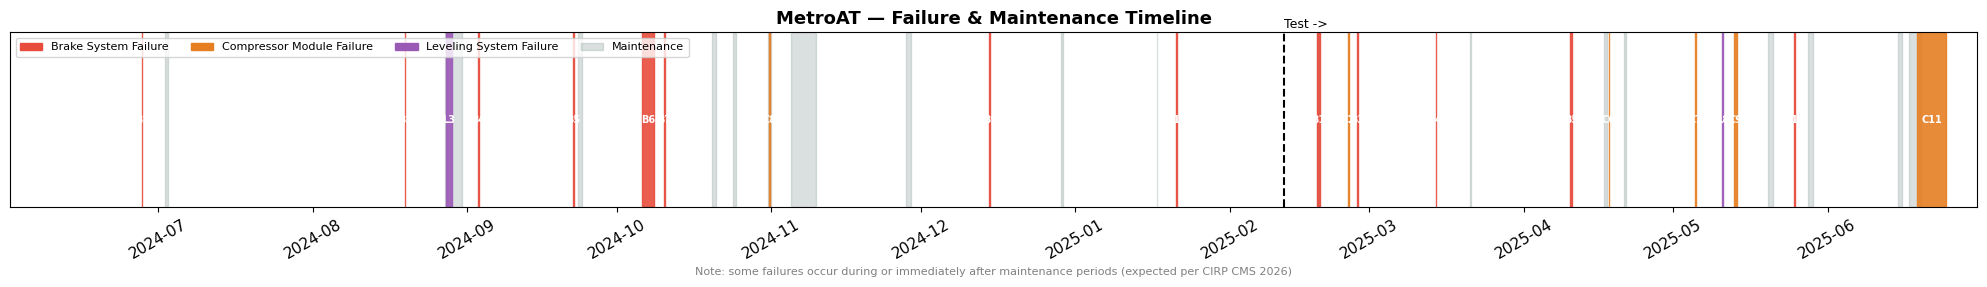


Failures overlapping with maintenance:
                     failure          fail_start       maintenance         maint_start
0    Leveling System Failure 2024-08-27 15:58:43  48-week-Revision 2024-08-27 14:31:21
1  Compressor Module Failure 2024-10-31 15:08:06   Spot Inspection 2024-10-31 07:12:23
2       Brake System Failure 2025-02-18 14:40:40  24-week-Revision 2025-02-18 14:40:40
3  Compressor Module Failure 2025-06-18 22:53:40       No Revision 2025-06-17 06:13:49


In [8]:
fig, ax = plt.subplots(figsize=(20, 3))

# Maintenance blocks (drawn first, behind failures)
for _, row in pd.concat([train_maint, test_maint]).iterrows():
    ax.axvspan(row['start'], row['end'], color=MAINT_COLOR, alpha=0.35, zorder=0)

# Train/test split line
split_date = train['TIMESTAMP'].max()
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5, zorder=3)
ax.text(split_date, 1.01, 'Test ->', transform=ax.get_xaxis_transform(),
        va='bottom', ha='left', fontsize=9)

# Failure events (drawn on top)
for events in [train_events, test_events]:
    for idx, row in events.iterrows():
        color = TYPE_COLORS.get(row['failure_type'], 'grey')
        ax.axvspan(row['start'], row['end'], color=color, alpha=0.9, zorder=2)
        # Label: first letter of subsystem + event number
        lbl = row['failure_type'][0] + str(idx)
        ax.text(row['start'] + (row['end'] - row['start']) / 2, 0.5,
                lbl, transform=ax.get_xaxis_transform(),
                va='center', ha='center', fontsize=7, color='white', fontweight='bold')

# Legend
from matplotlib.patches import Patch
patches  = [Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
patches += [Patch(color=MAINT_COLOR, alpha=0.35, label='Maintenance')]
ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=4)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.set_yticks([])
ax.set_xlim(train['TIMESTAMP'].min(), test['TIMESTAMP'].max())
ax.set_title('MetroAT — Failure & Maintenance Timeline', fontsize=13, fontweight='bold')
ax.set_xlabel('Note: some failures occur during or immediately after maintenance periods (expected per CIRP CMS 2026)',
              fontsize=8, color='grey')
plt.tight_layout()
plt.show()

# Print overlaps explicitly
overlap_summary = []
all_maint = pd.concat([train_maint.assign(split='train'), test_maint.assign(split='test')])
all_fail  = pd.concat([train_events.assign(split='train'), test_events.assign(split='test')])
for _, f in all_fail.iterrows():
    for _, m in all_maint.iterrows():
        if f['start'] <= m['end'] and f['end'] >= m['start']:
            overlap_summary.append({'failure': f['failure_type'], 'fail_start': f['start'],
                                    'maintenance': m['mtype'], 'maint_start': m['start']})
if overlap_summary:
    print('\nFailures overlapping with maintenance:')
    print(pd.DataFrame(overlap_summary).to_string())

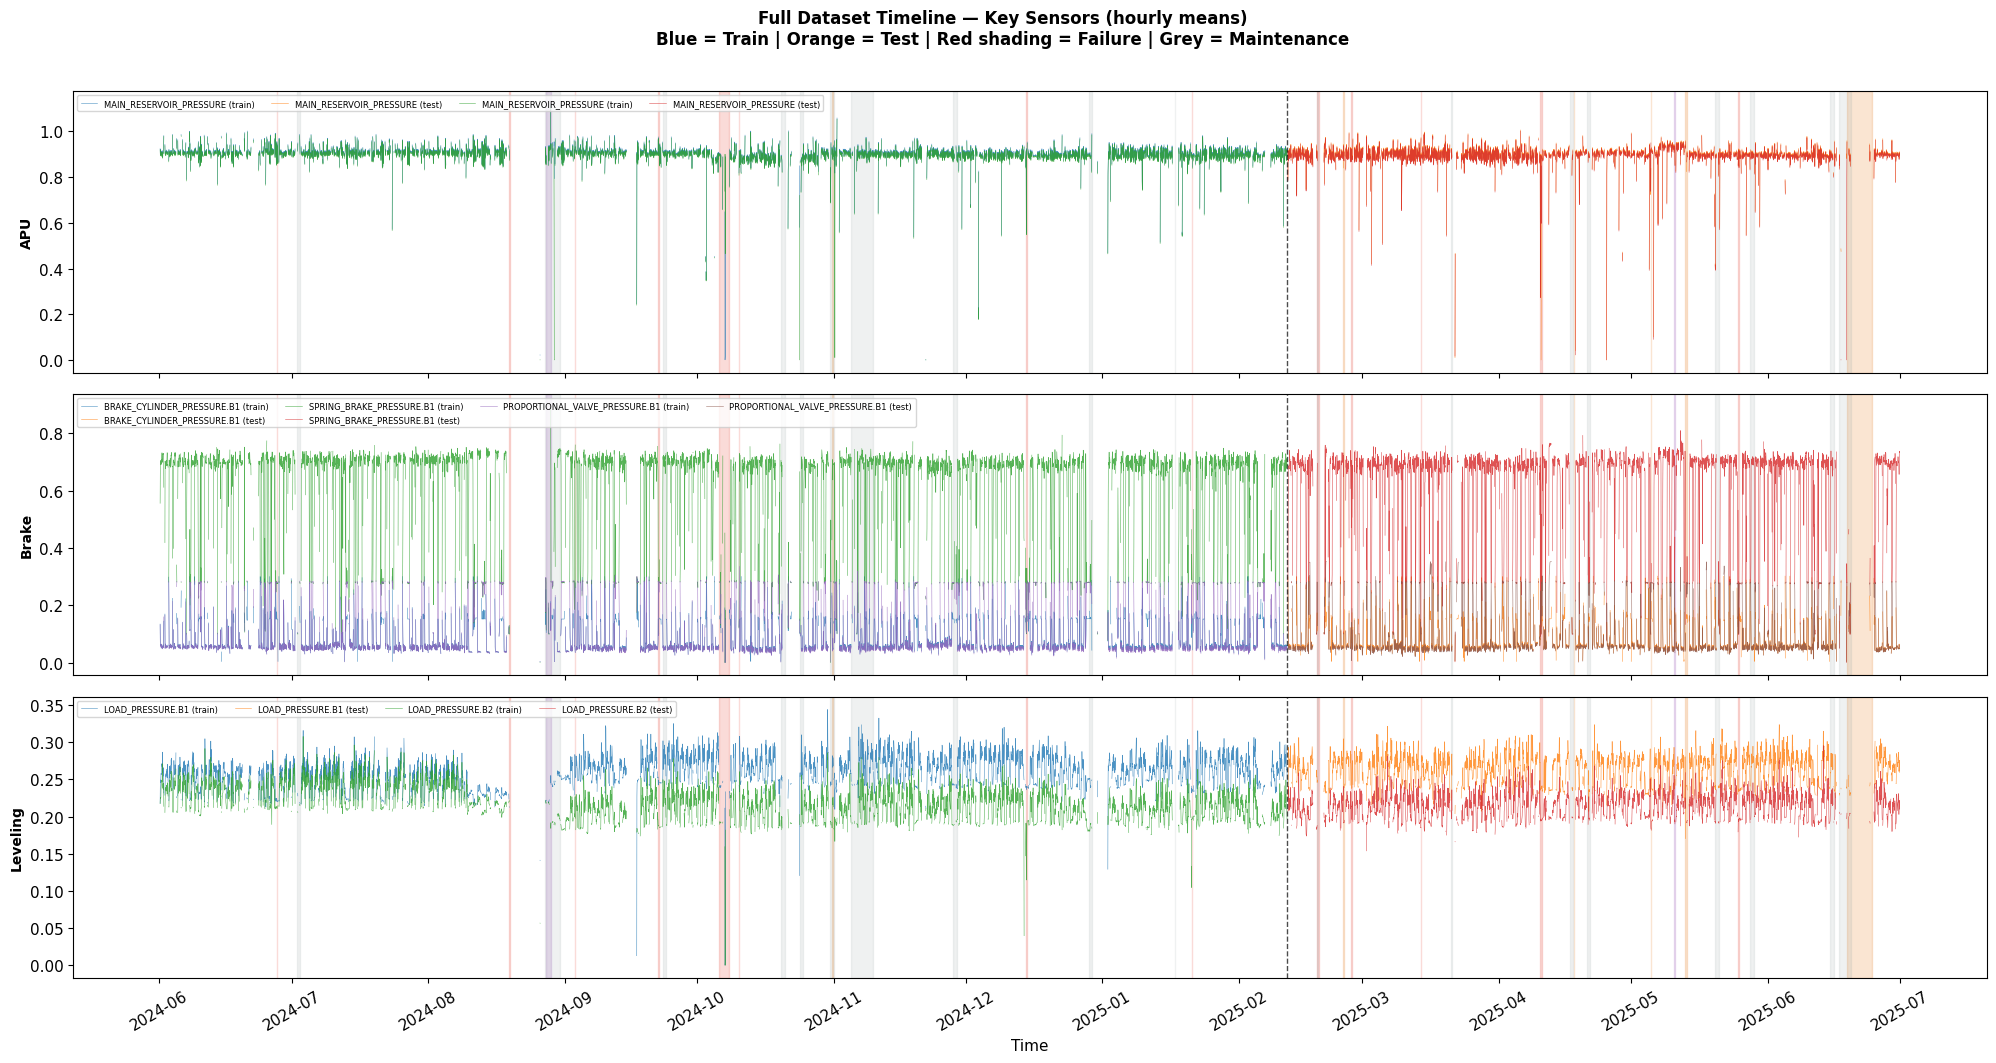

Full-timeline sensor plots complete.


In [9]:
# Full-timeline sensor plots — hourly downsampled (train + test)
PLOT_SENSORS = {
    'APU':      ['CW1_MAIN_RESERVOIR_PRESSURE', 'CW2_MAIN_RESERVOIR_PRESSURE'],
    'Brake':    ['CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_SPRING_BRAKE_PRESSURE_BOGIE1',
                 'CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1'],
    'Leveling': ['CW1_LOAD_PRESSURE_BOGIE1', 'CW1_LOAD_PRESSURE_BOGIE2'],
}

all_plot_cols = [s for sensors in PLOT_SENSORS.values() for s in sensors]

# Resample to hourly means for tractable plotting
train_h = train[['TIMESTAMP'] + all_plot_cols].set_index('TIMESTAMP').resample('1h').mean()
test_h  = test[['TIMESTAMP'] + all_plot_cols].set_index('TIMESTAMP').resample('1h').mean()

split_date = train['TIMESTAMP'].max()

fig, axes = plt.subplots(len(PLOT_SENSORS), 1, figsize=(20, 3.5 * len(PLOT_SENSORS)), sharex=True)
fig.suptitle('Full Dataset Timeline — Key Sensors (hourly means)\nBlue = Train | Orange = Test | Red shading = Failure | Grey = Maintenance',
             fontsize=12, fontweight='bold', y=1.01)

for ax, (subsystem, sensors) in zip(axes, PLOT_SENSORS.items()):
    for sensor in sensors:
        label = sensor.replace('CW1_', '').replace('CW2_', '').replace('_BOGIE1', '.B1').replace('_BOGIE2', '.B2')
        ax.plot(train_h.index, train_h[sensor], linewidth=0.4, alpha=0.8, label=f'{label} (train)')
        ax.plot(test_h.index, test_h[sensor], linewidth=0.4, alpha=0.8, label=f'{label} (test)')

    # Failure events
    for events in [train_events, test_events]:
        for _, ev in events.iterrows():
            color = TYPE_COLORS.get(ev['failure_type'], 'grey')
            ax.axvspan(ev['start'], ev['end'], color=color, alpha=0.2, zorder=0)

    # Maintenance events
    for _, m in pd.concat([train_maint, test_maint]).iterrows():
        ax.axvspan(m['start'], m['end'], color=MAINT_COLOR, alpha=0.15, zorder=0)

    # Train/test split
    ax.axvline(split_date, color='black', linestyle='--', linewidth=1, alpha=0.7)

    ax.set_ylabel(subsystem, fontsize=10, fontweight='bold')
    ax.legend(fontsize=6, loc='upper left', ncol=4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].set_xlabel('Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

del train_h, test_h; gc.collect()
print('Full-timeline sensor plots complete.')

### Sensor Distributions: Normal vs Failure

Compare how key sensor values differ between normal operation and failure periods.  
This motivates which sensors carry discriminative signal for predictive maintenance.

In [10]:
# Compare sensor distributions: normal operation vs during failure (train set)
# Use boolean masks without copying the full dataframe
normal_mask  = ~train['TRAIN_IS_IN_FAILURE'] & ~train['TRAIN_IS_IN_MAINTENANCE']
failure_mask = train['TRAIN_IS_IN_FAILURE'].astype(bool)

key_sensors = [
    'CW1_MAIN_RESERVOIR_PRESSURE', 'CW2_MAIN_RESERVOIR_PRESSURE',
    'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_SPRING_BRAKE_PRESSURE_BOGIE1',
    'CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1',
    'CW1_LOAD_PRESSURE_BOGIE1', 'CW1_LOAD_SIGNAL',
]

# Compute stats column-by-column to avoid large intermediate copies
rows = []
for s in key_sensors:
    col = train[s]
    rows.append({
        'sensor': s,
        'subsystem': get_subsystem(s),
        'normal_mean':  float(col[normal_mask].mean()),
        'normal_std':   float(col[normal_mask].std()),
        'failure_mean': float(col[failure_mask].mean()),
        'failure_std':  float(col[failure_mask].std()),
    })
stats = pd.DataFrame(rows).set_index('sensor')
stats['mean_diff'] = (stats['failure_mean'] - stats['normal_mean']).round(4)
print(stats[['subsystem','normal_mean','failure_mean','mean_diff','normal_std','failure_std']].round(4).to_string())

                                       subsystem  normal_mean  failure_mean  mean_diff  normal_std  failure_std
sensor                                                                                                         
CW1_MAIN_RESERVOIR_PRESSURE                  APU       0.9038        0.8557    -0.0481      0.0597       0.2110
CW2_MAIN_RESERVOIR_PRESSURE                  APU       0.8989        0.8821    -0.0168      0.0605       0.1414
CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1         Brake       0.0755        0.1248     0.0493      0.1017       0.1218
CW1_SPRING_BRAKE_PRESSURE_BOGIE1           Brake       0.6157        0.3141    -0.3017      0.1983       0.2323
CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1     Brake       0.0950        0.1826     0.0876      0.1112       0.1118
CW1_LOAD_PRESSURE_BOGIE1                Leveling       0.2619        0.2262    -0.0357      0.0343       0.0545
CW1_LOAD_SIGNAL                         Leveling       0.0624        0.0522    -0.0102      0.1104      

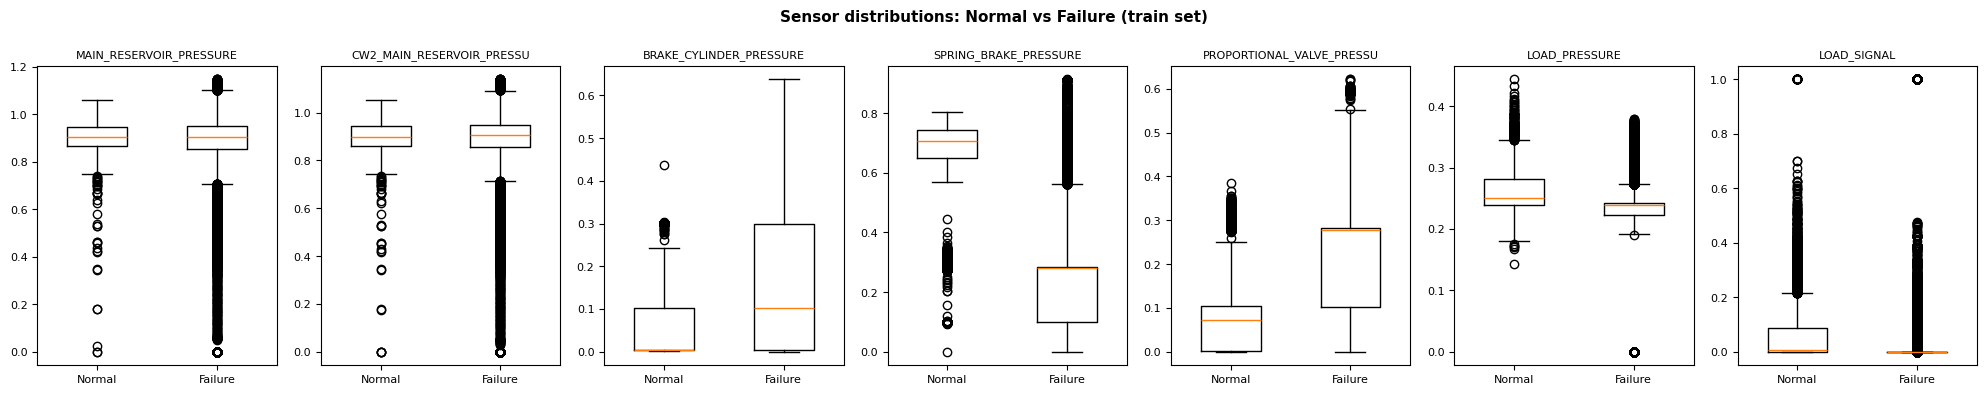

21304

In [11]:
# Box plots: normal vs failure for key sensors
fig, axes = plt.subplots(1, len(key_sensors), figsize=(20, 4))
for ax, sensor in zip(axes, key_sensors):
    col = train[sensor]
    norm_vals = col[normal_mask].dropna()
    fail_vals = col[failure_mask].dropna()
    # Sample normal to keep plot manageable
    if len(norm_vals) > 10000:
        norm_vals = norm_vals.sample(10000, random_state=42)
    data = [norm_vals, fail_vals]
    ax.boxplot(data, labels=['Normal', 'Failure'], widths=0.5)
    short = sensor.replace('CW1_','').replace('_BOGIE1','')[:25]
    ax.set_title(short, fontsize=8)
    ax.tick_params(labelsize=8)
plt.suptitle('Sensor distributions: Normal vs Failure (train set)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close(fig)

del normal_mask, failure_mask; gc.collect()

## 5. Precursor Signal Analysis — Full Timeline

Rolling variance of the main reservoir pressure sensors over the **entire** train + test period.  
Variance spikes before failure events indicate detectable precursor signals.  
Rolling window = τ_corr ≈ 410s (Steiner RAMS 2026).

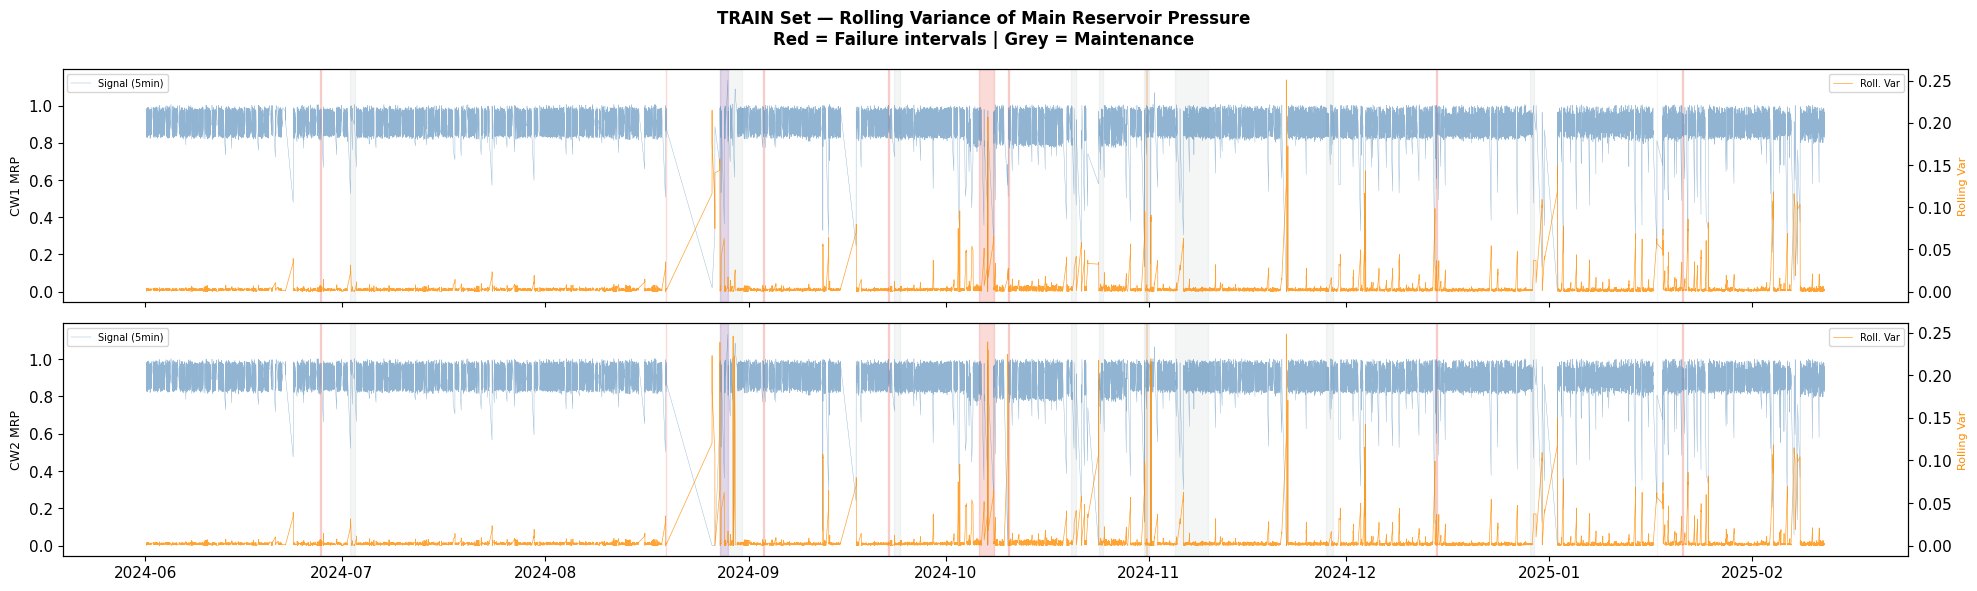

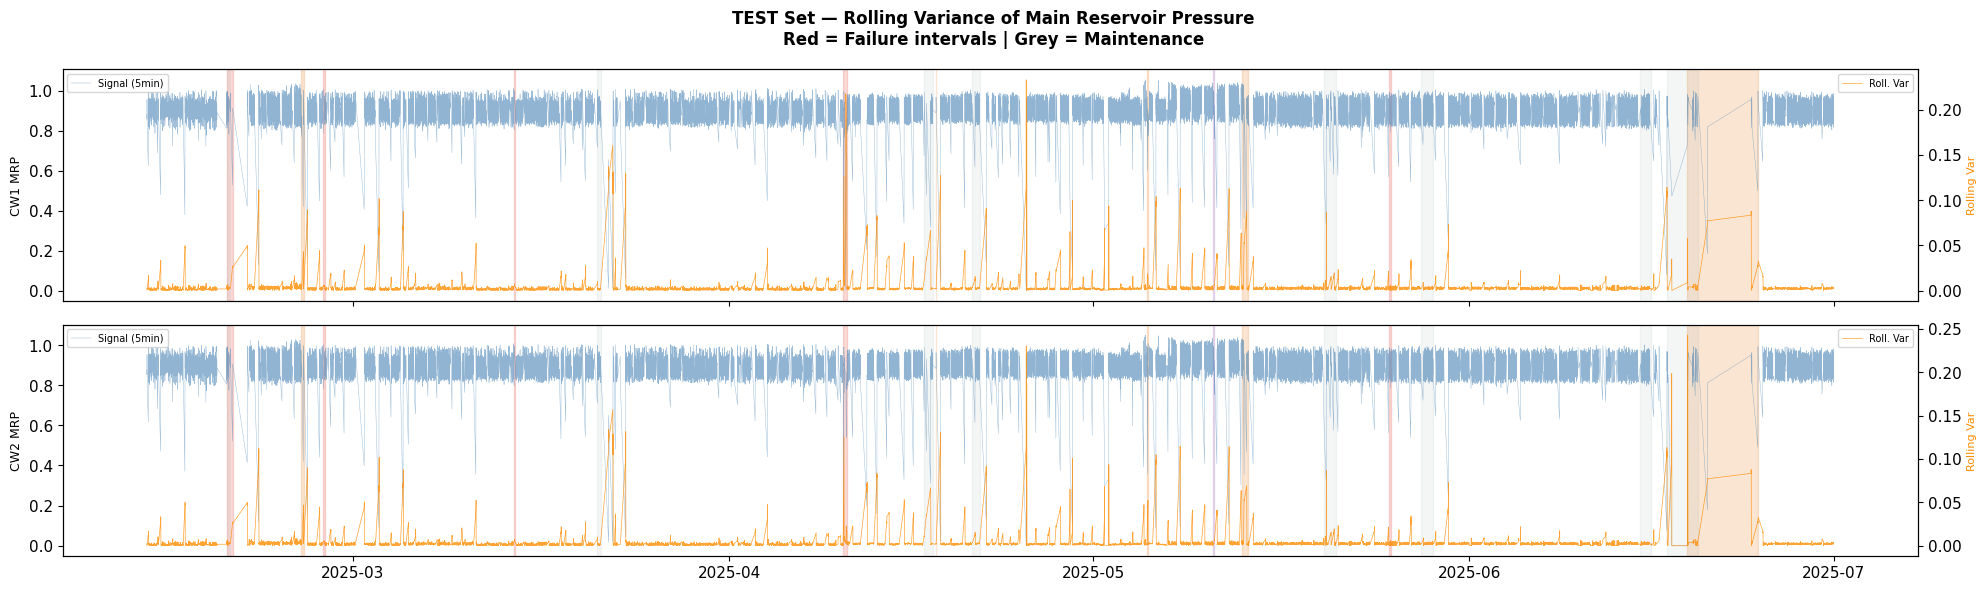

Full-timeline rolling variance plots complete.


In [12]:
# Full-timeline rolling variance for main reservoir pressure
PRECURSOR_SENSORS = ['CW1_MAIN_RESERVOIR_PRESSURE', 'CW2_MAIN_RESERVOIR_PRESSURE']
TAU_CORR_S = 410
RESAMPLE_S = '5min'  # downsample to 5-min means first, then compute rolling var

precursor_results = []

for split_label, df, events in [('TRAIN', train, train_events), ('TEST', test, test_events)]:
    fig, axes = plt.subplots(len(PRECURSOR_SENSORS), 1, figsize=(20, 3 * len(PRECURSOR_SENSORS)), sharex=True)
    fig.suptitle(f'{split_label} Set — Rolling Variance of Main Reservoir Pressure\n'
                 f'Red = Failure intervals | Grey = Maintenance',
                 fontsize=12, fontweight='bold')

    for ax, sensor in zip(axes, PRECURSOR_SENSORS):
        # Downsample to 5-min means to keep memory manageable
        s = df[['TIMESTAMP', sensor]].set_index('TIMESTAMP')[sensor].dropna()
        s_ds = s.resample(RESAMPLE_S).mean().dropna()

        # Rolling variance over ~7 data points (7 × 5min ≈ 35min ≈ τ_corr)
        rv = s_ds.rolling(7, min_periods=3).var()

        # Plot signal on primary axis
        ax.plot(s_ds.index, s_ds.values, linewidth=0.3, color='steelblue', alpha=0.6, label=f'Signal (5min)')

        # Plot rolling variance on secondary axis
        ax2 = ax.twinx()
        ax2.plot(rv.index, rv.values, linewidth=0.5, color='darkorange', alpha=0.8, label='Roll. Var')
        ax2.set_ylabel('Rolling Var', fontsize=8, color='darkorange')

        # Failure events
        for _, ev in events.iterrows():
            color = TYPE_COLORS.get(ev['failure_type'], 'grey')
            ax.axvspan(ev['start'], ev['end'], color=color, alpha=0.2, zorder=0)

        # Maintenance
        maint = train_maint if split_label == 'TRAIN' else test_maint
        for _, m in maint.iterrows():
            ax.axvspan(m['start'], m['end'], color=MAINT_COLOR, alpha=0.1, zorder=0)

        short = sensor.replace('_MAIN_RESERVOIR_PRESSURE', ' MRP')
        ax.set_ylabel(short, fontsize=9)
        ax.legend(fontsize=7, loc='upper left')
        ax2.legend(fontsize=7, loc='upper right')

        # Collect peak variance stats for each failure event
        for idx, ev in events.iterrows():
            pre_window = rv[(rv.index >= ev['start'] - pd.Timedelta(hours=24)) &
                           (rv.index < ev['start'])]
            if len(pre_window) > 0:
                peak_time = pre_window.idxmax()
                lead_h = (ev['start'] - peak_time).total_seconds() / 3600
                precursor_results.append({
                    'split': split_label, 'event': idx,
                    'failure_type': ev['failure_type'],
                    'sensor': sensor,
                    'peak_var': round(float(pre_window.max()), 6),
                    'lead_h': round(lead_h, 2)
                })

        del s, s_ds, rv
        gc.collect()

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

gc.collect()
print('Full-timeline rolling variance plots complete.')

In [13]:
# Precursor detection summary across all events (train + test)
prec_df = pd.DataFrame(precursor_results)
if len(prec_df) > 0:
    print('=== Precursor Summary (train + test) ===')
    summary = (
        prec_df.groupby(['split', 'event', 'failure_type', 'sensor'])
        .agg(peak_var=('peak_var', 'max'), lead_h=('lead_h', 'min'))
        .reset_index()
    )
    print(summary[['split', 'event', 'failure_type', 'sensor', 'peak_var', 'lead_h']].to_string(index=False))
    print()
    print(f'Median lead time to peak variance spike: {prec_df["lead_h"].median():.1f}h')
    print(f'Events with detectable precursor: {len(prec_df)} / {len(train_events) + len(test_events)} event-sensor pairs')
else:
    print('No precursor results collected.')

=== Precursor Summary (train + test) ===
split  event              failure_type                      sensor  peak_var  lead_h
 TEST      1      Brake System Failure CW1_MAIN_RESERVOIR_PRESSURE  0.004352   21.51
 TEST      1      Brake System Failure CW2_MAIN_RESERVOIR_PRESSURE  0.004304   21.51
 TEST      2 Compressor Module Failure CW1_MAIN_RESERVOIR_PRESSURE  0.016377   12.83
 TEST      2 Compressor Module Failure CW2_MAIN_RESERVOIR_PRESSURE  0.016403   12.83
 TEST      3      Brake System Failure CW1_MAIN_RESERVOIR_PRESSURE  0.044301    6.08
 TEST      3      Brake System Failure CW2_MAIN_RESERVOIR_PRESSURE  0.044693    6.08
 TEST      4      Brake System Failure CW1_MAIN_RESERVOIR_PRESSURE  0.005287   11.11
 TEST      4      Brake System Failure CW2_MAIN_RESERVOIR_PRESSURE  0.005448   11.11
 TEST      5      Brake System Failure CW1_MAIN_RESERVOIR_PRESSURE  0.011572    5.08
 TEST      5      Brake System Failure CW2_MAIN_RESERVOIR_PRESSURE  0.011697    5.08
 TEST      6 Compressor 

## 6. Missing Values Analysis

Identify which sensors have missing values, how many, and whether they cluster in time.

Sensors with missing values: 3 / 101
TRAIN_LINE                  155286
TRAIN_CURRENT_SECTION       155286
TRAIN_IS_SPECIAL_SECTION    155286


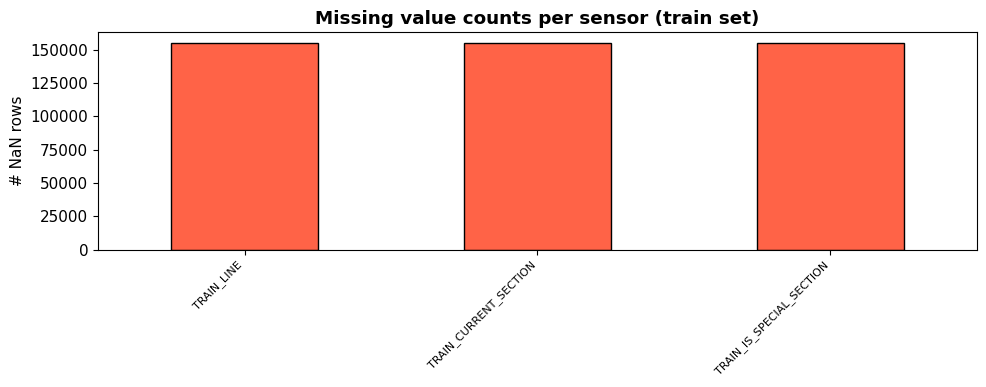

In [14]:
# Compute null counts column-by-column to avoid MemoryError
sensor_cols = [c for c in train.columns if c not in META_COLS]
null_counts = pd.Series({c: int(train[c].isnull().sum()) for c in sensor_cols})
null_cols   = null_counts[null_counts > 0].sort_values(ascending=False)

print(f'Sensors with missing values: {len(null_cols)} / {len(sensor_cols)}')
print(null_cols.to_string())

if len(null_cols) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(null_cols)*0.5), 4))
    null_cols.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Missing value counts per sensor (train set)', fontweight='bold')
    ax.set_ylabel('# NaN rows')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print('No missing values in sensor columns.')

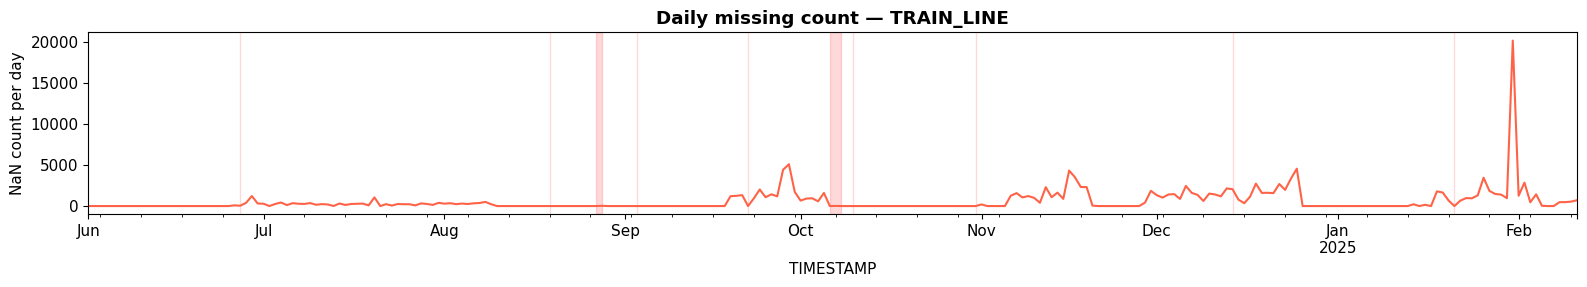

Missing rows in failure periods:     63
Missing rows in maintenance periods: 6,088
Missing rows in normal periods:      149,166


In [15]:
# Missing values distribution over time (daily count)
if len(null_cols) > 0:
    top_sensor = null_cols.index[0]
    # Select only 2 columns before set_index — avoids consolidating all 109 cols
    daily_null = (
        train[['TIMESTAMP', top_sensor]]
        .set_index('TIMESTAMP')[top_sensor]
        .isnull()
        .resample('D')
        .sum()
    )
    fig, ax = plt.subplots(figsize=(16, 3))
    daily_null.plot(ax=ax, color='tomato')
    ax.set_title(f'Daily missing count — {top_sensor}', fontweight='bold')
    ax.set_ylabel('NaN count per day')
    for _, ev in train_events.iterrows():
        ax.axvspan(ev['start'], ev['end'], color='red', alpha=0.15)
    plt.tight_layout()
    plt.show()

    is_null  = train[top_sensor].isnull()
    in_fail  = train['TRAIN_IS_IN_FAILURE']
    in_maint = train['TRAIN_IS_IN_MAINTENANCE']
    print(f'Missing rows in failure periods:     {(is_null & in_fail).sum():,}')
    print(f'Missing rows in maintenance periods: {(is_null & in_maint).sum():,}')
    print(f'Missing rows in normal periods:      {(is_null & ~in_fail & ~in_maint).sum():,}')

## 7. Decorrelation Time (τ_corr) Validation

Steiner RAMS 2026 reports τ_corr ≈ 410s (median IQR 343–499s) computed from the HBL_DRUCK (main reservoir pressure) ACF.  
We validate this on our dataset using the CW1 main reservoir pressure signal in normal operating periods.

In [16]:
from scipy import signal as scipy_signal

ACF_SENSOR   = 'CW1_MAIN_RESERVOIR_PRESSURE'
MAX_LAG_S    = 1200     # show up to 20min
MIN_ROWS     = 3600     # minimum rows in segment for reliable ACF

# Select only needed columns before filtering — avoids copying all 109 cols (MemoryError)
mask      = ~train['TRAIN_IS_IN_FAILURE'] & ~train['TRAIN_IS_IN_MAINTENANCE']
normal_ts = (train.loc[mask, ['TIMESTAMP', ACF_SENSOR]]
             .set_index('TIMESTAMP').sort_index())

# Split into day-long segments and compute ACF for each
tau_corrs = []

days = pd.date_range(normal_ts.index.min().date(), normal_ts.index.max().date(), freq='D')
for day in days:
    seg = normal_ts.loc[str(day.date()), ACF_SENSOR].dropna()
    if len(seg) < MIN_ROWS:
        continue

    # Stationarize: subtract rolling mean (5min window)
    rm = seg.rolling(300, min_periods=60, center=True).mean().ffill().bfill()
    s  = (seg - rm).values
    s  = (s - s.mean()) / (s.std() + 1e-10)

    # Full ACF via FFT
    n    = len(s)
    fft  = np.fft.rfft(s, n=2*n)
    acf  = np.fft.irfft(fft * np.conj(fft))[:n]
    acf  = acf / (acf[0] + 1e-10)

    # First zero-crossing (τ_corr)
    zero_crossings = np.where(np.diff(np.sign(acf[:MAX_LAG_S])))[0]
    if len(zero_crossings) > 0:
        tau_corrs.append(zero_crossings[0])

tau_corrs = np.array(tau_corrs)
print(f'Segments analysed : {len(tau_corrs)}')
print(f'τ_corr  median    : {np.median(tau_corrs):.0f}s')
print(f'τ_corr  IQR       : {np.percentile(tau_corrs,25):.0f}s – {np.percentile(tau_corrs,75):.0f}s')
print(f'Steiner reference : 410s (IQR 343–499s)')
print()
print('Window candidate validity:')
for w_min in [6, 11.5, 23]:
    w_s = w_min * 60
    ratio = w_s / np.median(tau_corrs)
    print(f'  {w_min:5.1f}min ({w_s:.0f}s) = {ratio:.1f}× τ_corr  → {"✓ independent" if ratio >= 1 else "⚠ correlated"}')

Segments analysed : 222
τ_corr  median    : 92s
τ_corr  IQR       : 85s – 98s
Steiner reference : 410s (IQR 343–499s)

Window candidate validity:
    6.0min (360s) = 3.9× τ_corr  → ✓ independent
   11.5min (690s) = 7.5× τ_corr  → ✓ independent
   23.0min (1380s) = 15.0× τ_corr  → ✓ independent


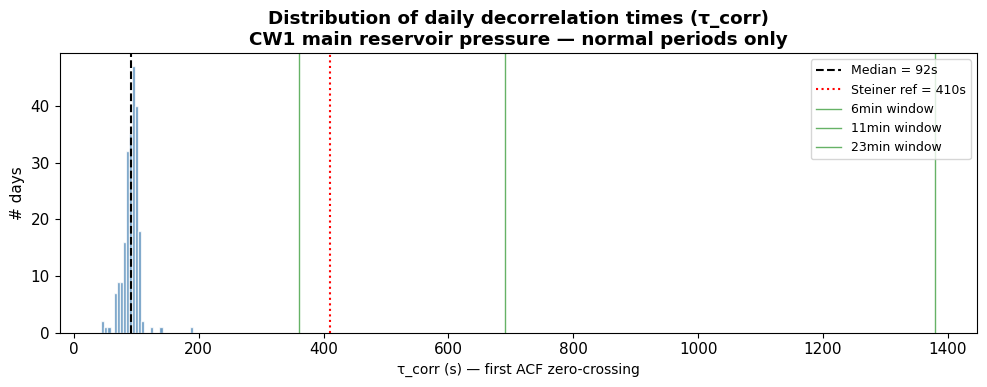

In [17]:
# Histogram of daily τ_corr values + window size markers
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tau_corrs, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.median(tau_corrs), color='black', linewidth=1.5, linestyle='--',
           label=f'Median = {np.median(tau_corrs):.0f}s')
ax.axvline(410, color='red', linewidth=1.5, linestyle=':', label='Steiner ref = 410s')
for w in [6*60, int(11.5*60), 23*60]:
    ax.axvline(w, color='green', linewidth=1, linestyle='-', alpha=0.6, label=f'{w//60}min window')
ax.set_xlabel('τ_corr (s) — first ACF zero-crossing', fontsize=10)
ax.set_ylabel('# days')
ax.set_title('Distribution of daily decorrelation times (τ_corr)\nCW1 main reservoir pressure — normal periods only', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Subsystem Correlation Heatmap

Pearson correlations between sensors, grouped by subsystem.  
High within-subsystem correlation confirms that sensors within a subsystem share information, motivating subsystem-level aggregation in feature engineering.

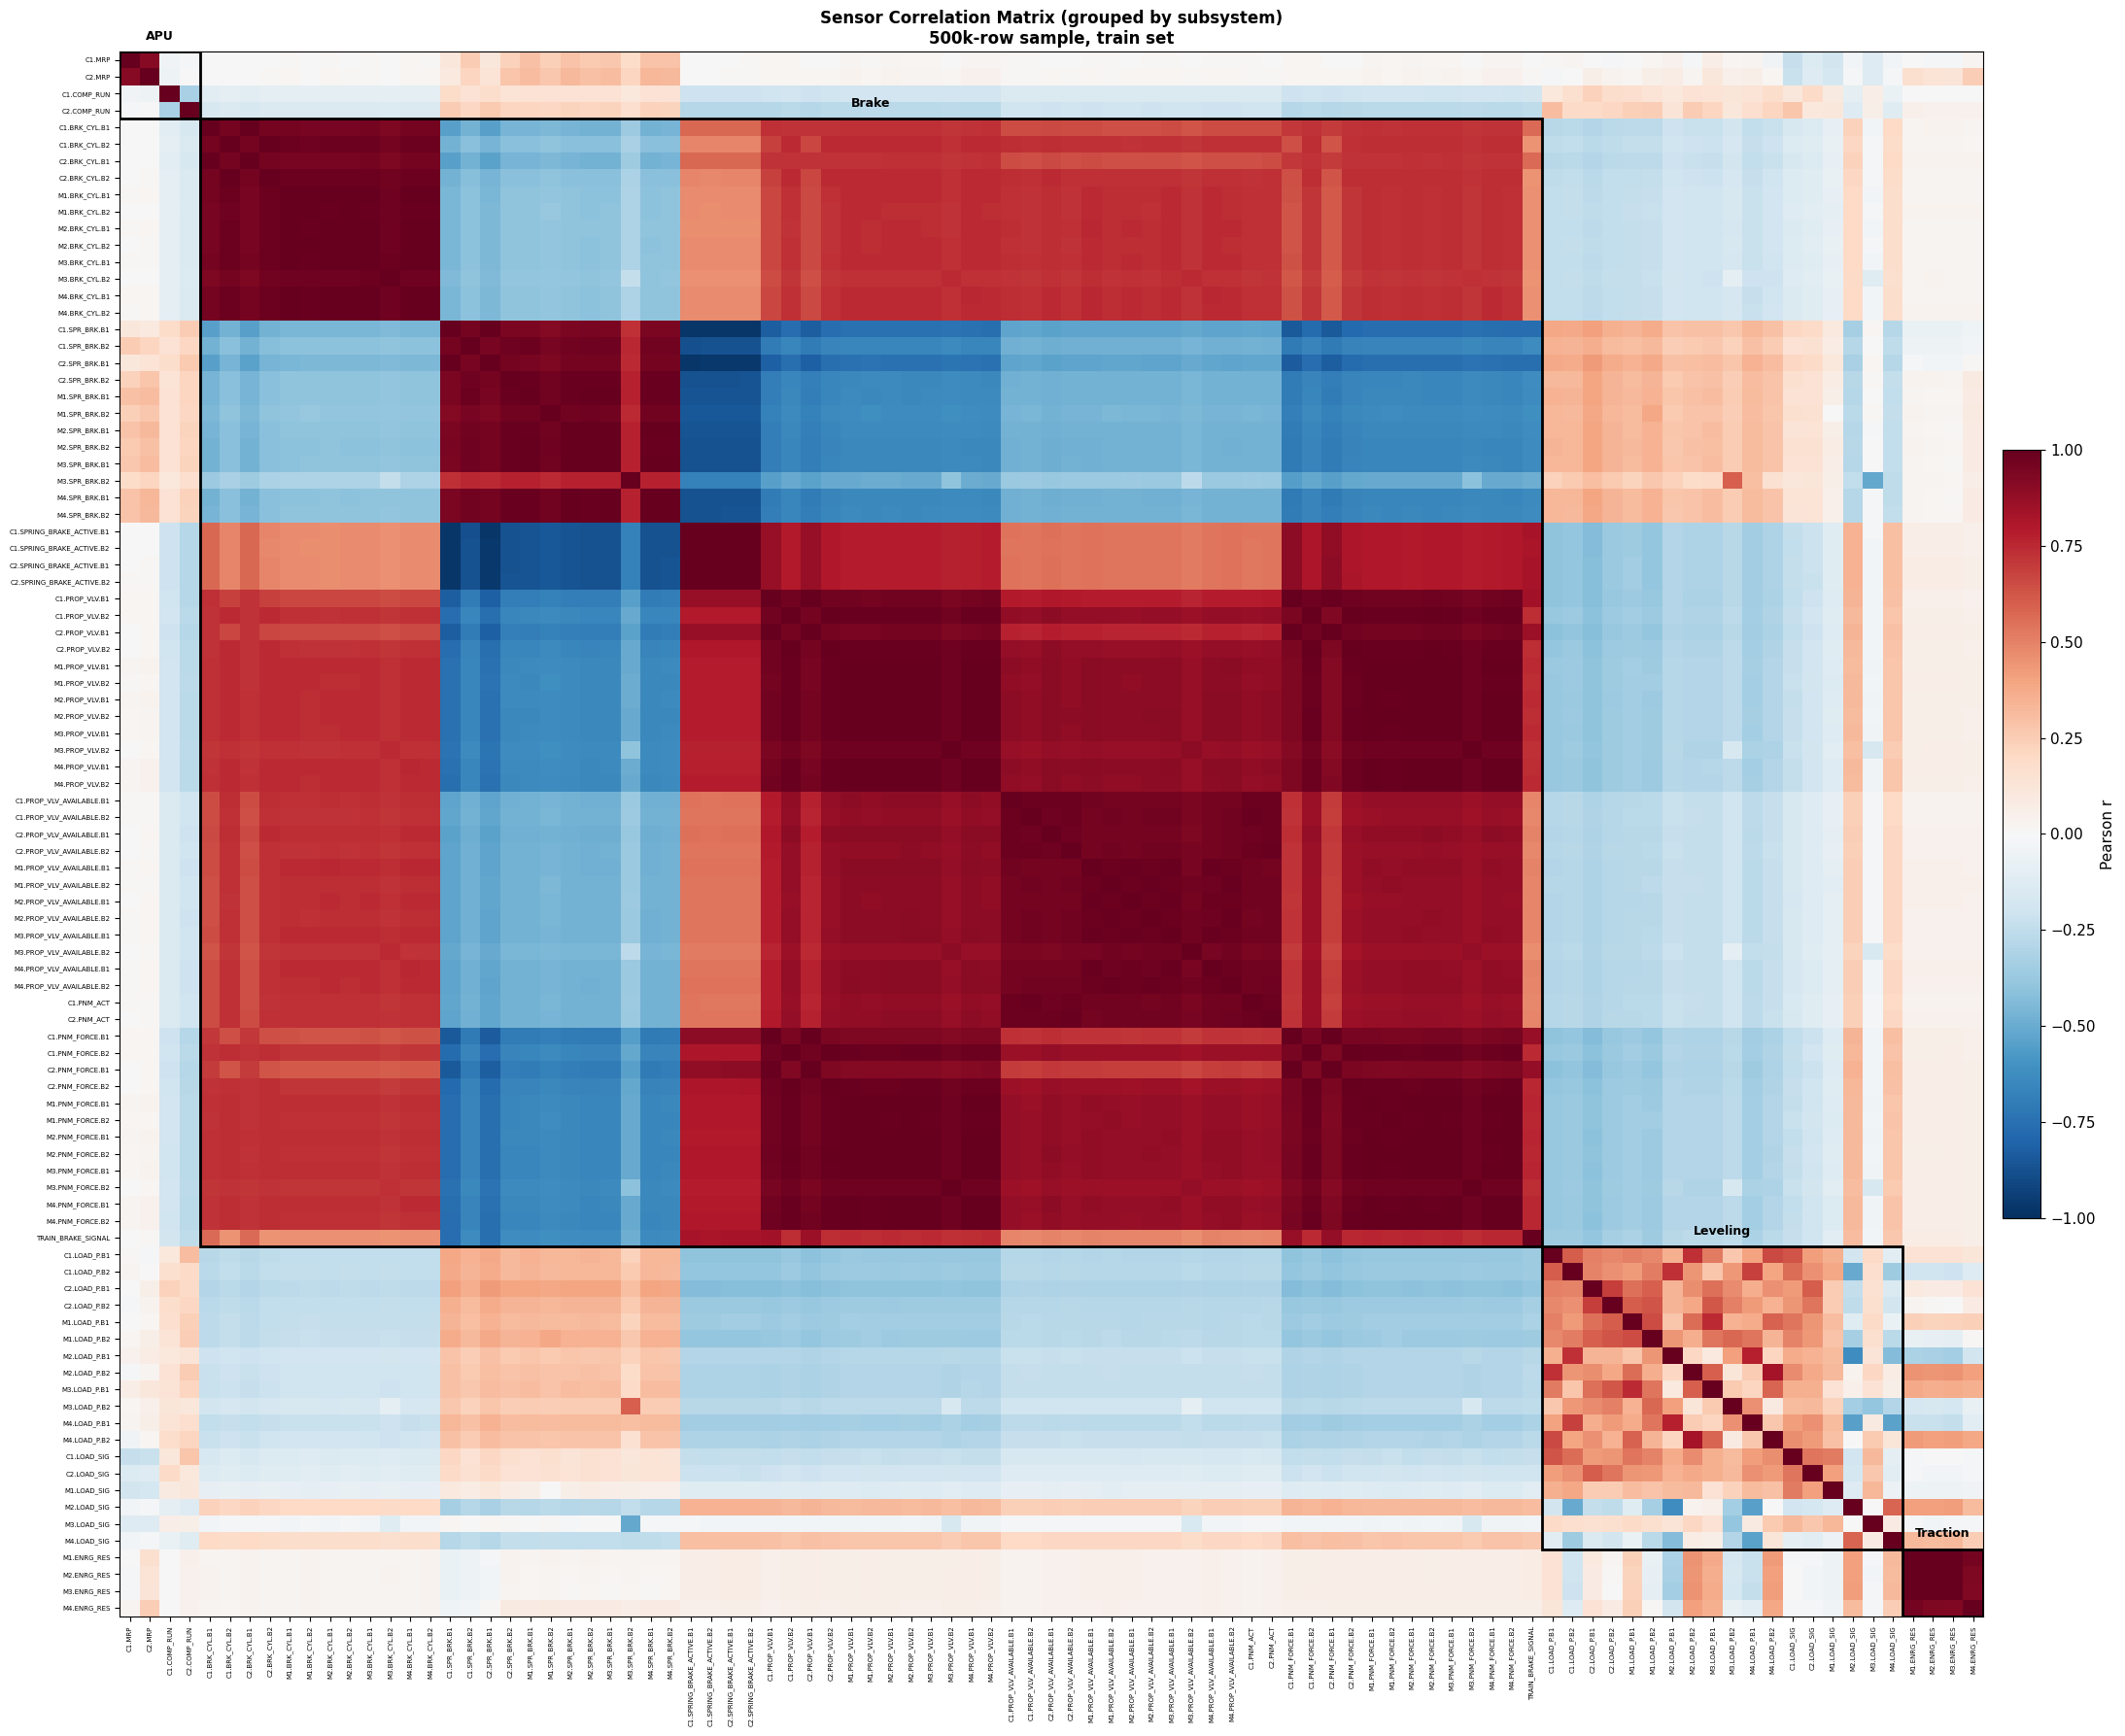

Mean |Pearson r|:
  Within  APU       : 0.225
  Within  Brake     : 0.746
  Within  Leveling  : 0.369
  Within  Traction  : 0.968
  APU        <-> Brake     : 0.125
  APU        <-> Leveling  : 0.110
  Brake      <-> Leveling  : 0.253


In [18]:
from src.config import SUBSYSTEMS

# Collect sensors in subsystem order (exclude Context — mostly categorical/binary flags)
CORR_SUBSYSTEMS = ['APU', 'Brake', 'Leveling', 'Traction']
ordered_cols = []
boundaries   = []
for ss in CORR_SUBSYSTEMS:
    start = len(ordered_cols)
    cols  = [c for c in SUBSYSTEMS[ss] if c in train.columns]
    ordered_cols.extend(cols)
    boundaries.append((start, len(ordered_cols), ss))

# Sample 500k rows and only the needed columns — avoids copying all 109 cols
sample = train[ordered_cols].sample(min(500_000, len(train)), random_state=42)
corr_matrix = sample.corr()
del sample; gc.collect()

def shorten_label(c):
    """Shorten sensor names to unique, readable abbreviations."""
    c = c.replace('CW1_', 'C1.').replace('CW2_', 'C2.')
    c = c.replace('MW1_', 'M1.').replace('MW2_', 'M2.').replace('MW3_', 'M3.').replace('MW4_', 'M4.')
    c = c.replace('_BOGIE1', '.B1').replace('_BOGIE2', '.B2')
    c = c.replace('MAIN_RESERVOIR_PRESSURE', 'MRP').replace('COMPRESSOR_RUNNING', 'COMP_RUN')
    c = c.replace('BRAKE_CYLINDER_PRESSURE', 'BRK_CYL').replace('SPRING_BRAKE_PRESSURE', 'SPR_BRK')
    c = c.replace('PROPORTIONAL_VALVE_PRESSURE', 'PROP_VLV').replace('PNEUMATIC_BRAKING_FORCE', 'PNM_FORCE')
    c = c.replace('PNEUMATIC_BRAKE_ACTIVE', 'PNM_ACT')
    c = c.replace('LOAD_PRESSURE', 'LOAD_P').replace('LOAD_SIGNAL', 'LOAD_SIG')
    c = c.replace('ENERGY_BRAKING_RESISTANCE', 'ENRG_RES')
    return c

tick_labels = [shorten_label(c) for c in ordered_cols]

# Verify all labels are unique
assert len(tick_labels) == len(set(tick_labels)), \
    f"Duplicate labels found!"

fig, ax = plt.subplots(figsize=(22, 18))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Pearson r')

for start, end, name in boundaries:
    rect = plt.Rectangle(
        (start - 0.5, start - 0.5), end - start, end - start,
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(start + (end - start) / 2 - 0.5, start - 1.2,
            name, fontsize=9, fontweight='bold', ha='center', color='black')

ax.set_xticks(range(len(ordered_cols)))
ax.set_yticks(range(len(ordered_cols)))
ax.set_xticklabels(tick_labels, rotation=90, fontsize=5)
ax.set_yticklabels(tick_labels, fontsize=5)
ax.set_title('Sensor Correlation Matrix (grouped by subsystem)\n500k-row sample, train set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close(fig)

# Print within-subsystem vs cross-subsystem mean |r|
print('Mean |Pearson r|:')
for s1, e1, n1 in boundaries:
    within = np.abs(corr_matrix.iloc[s1:e1, s1:e1].values).copy()
    np.fill_diagonal(within, np.nan)
    print(f'  Within  {n1:10s}: {np.nanmean(within):.3f}')
for (s1,e1,n1),(s2,e2,n2) in [
    (boundaries[0],boundaries[1]), (boundaries[0],boundaries[2]),
    (boundaries[1],boundaries[2])
]:
    cross = np.abs(corr_matrix.iloc[s1:e1, s2:e2].values)
    print(f'  {n1:10s} <-> {n2:10s}: {np.nanmean(cross):.3f}')

## 9. Asset Data: Failure & Revision History

Load the asset-level records from `data/asset_data/` to compute `days_since_last_failure` and `days_since_last_revision` — the two most important features in Stefan Helm's RF model.  
These are **not** in the sensor data; they must be computed from external maintenance records.

In [19]:
ASSET_DIR = os.path.join('..', 'data', 'asset_data')

failure_csv  = os.path.join(ASSET_DIR, 'failure.csv')
revision_csv = os.path.join(ASSET_DIR, 'revision.csv')

# Load with semicolon separator and UTF-8-BOM encoding (Stefan's format)
fail_df = pd.read_csv(failure_csv,   sep=';', encoding='utf-8-sig')
rev_df  = pd.read_csv(revision_csv,  sep=';', encoding='utf-8-sig')

print('=== failure.csv ===')
print(f'Shape: {fail_df.shape}')
print(fail_df.head(10).to_string())
print()
print('Columns:', fail_df.columns.tolist())
print()
print('=== revision.csv ===')
print(f'Shape: {rev_df.shape}')
print(rev_df.head(10).to_string())
print()
print('Columns:', rev_df.columns.tolist())

=== failure.csv ===
Shape: (41, 5)
  Störungsbeginn Störungsbeginn Zeit Störungsende Störungsende Zeit Subsystem Bezeichner
0     27.06.2024            15:47:30   27.06.2024          17:52:28          BREMSSYSTEM
1     19.08.2024            10:38:44   19.08.2024          13:06:53          BREMSSYSTEM
2     19.08.2024            10:39:07   19.08.2024          13:34:42          BREMSSYSTEM
3     19.08.2024            10:37:51   19.08.2024          12:05:32          BREMSSYSTEM
4     27.08.2024            19:47:56   28.08.2024          18:09:53         NIVEAUSYSTEM
5     27.08.2024            19:48:48   28.08.2024          16:13:02         NIVEAUSYSTEM
6     27.08.2024            15:58:43   28.08.2024          21:29:25         NIVEAUSYSTEM
7     28.08.2024            14:54:30   28.08.2024          20:46:36         NIVEAUSYSTEM
8     22.09.2024            05:49:43   22.09.2024          08:23:11          BREMSSYSTEM
9     10.10.2024            10:40:41   10.10.2024          15:35:49        

In [20]:
# Compute days_since_last_failure at each detected failure onset
# failure.csv has separate date (Störungsbeginn) and time (Störungsbeginn Zeit) columns

# Build full datetimes by combining date + time columns
def parse_failure_dates(df):
    """Parse failure.csv: combine date col + time col into full datetimes."""
    # Detect date column (contains date-like values, not pure times)
    for col in df.columns:
        vals = df[col].dropna().astype(str)
        # Date columns have dots (dd.mm.yyyy); time columns have colons only
        if vals.str.contains(r'\d{2}\.\d{2}\.\d{4}').any():
            # Found date column — look for matching time column
            time_col = None
            for tc in df.columns:
                if tc != col and vals.index.isin(df[tc].dropna().index).all():
                    tvals = df[tc].dropna().astype(str)
                    if tvals.str.match(r'^\d{2}:\d{2}').any():
                        time_col = tc
                        break
            if time_col:
                combined = df[col].astype(str) + ' ' + df[time_col].astype(str)
                return pd.to_datetime(combined, dayfirst=True, errors='coerce')
            else:
                return pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    return None

def parse_revision_dates(df):
    """Parse revision.csv: find start column containing date+time strings."""
    keywords = ['start', 'begin', 'beginn', 'datum', 'date']
    for col in df.columns:
        if any(kw in col.lower() for kw in keywords):
            parsed = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
            if parsed.notna().sum() > 0:
                return col, parsed
    return None, None

fail_dates = parse_failure_dates(fail_df)
rev_col, rev_dates = parse_revision_dates(rev_df)

print(f'Failure dates parsed  : {fail_dates.notna().sum()} / {len(fail_dates)}')
print(f'  Range: {fail_dates.min().date()} → {fail_dates.max().date()}')
print(f'Revision date column  : {rev_col}')
print(f'  Range: {rev_dates.min().date()} → {rev_dates.max().date()}')

# For each sensor-detected failure onset, compute days since last asset failure
sensor_onsets = pd.concat([train_events['start'], test_events['start']]).sort_values().values
fail_dates_sorted = fail_dates.dropna().sort_values().values

print(f'\nAsset failure records : {len(fail_dates_sorted)}')
print()
print('=== days_since_last_failure at each sensor-detected onset ===')
for onset in sensor_onsets:
    onset_ts = pd.Timestamp(onset)
    split    = 'TRAIN' if onset_ts <= pd.Timestamp('2025-02-11') else 'TEST'
    prior    = fail_dates_sorted[fail_dates_sorted < np.datetime64(onset_ts)]
    if len(prior) > 0:
        last = pd.Timestamp(prior[-1])
        days = (onset_ts - last).days
        print(f'  [{split}] {onset_ts.date()}  last_fail={last.date()}  days_since={days:4d}')
    else:
        print(f'  [{split}] {onset_ts.date()}  no prior failure on record')

Failure dates parsed  : 41 / 41
  Range: 2024-06-27 → 2025-08-23
Revision date column  : start
  Range: 2024-07-02 → 2025-07-29

Asset failure records : 41

=== days_since_last_failure at each sensor-detected onset ===
  [TRAIN] 2024-06-27  no prior failure on record
  [TRAIN] 2024-08-19  last_fail=2024-06-27  days_since=  52
  [TRAIN] 2024-08-27  last_fail=2024-08-19  days_since=   8
  [TRAIN] 2024-09-03  last_fail=2024-08-28  days_since=   5
  [TRAIN] 2024-09-22  last_fail=2024-09-03  days_since=  18
  [TRAIN] 2024-10-06  last_fail=2024-09-22  days_since=  13
  [TRAIN] 2024-10-10  last_fail=2024-10-06  days_since=   4
  [TRAIN] 2024-10-31  last_fail=2024-10-28  days_since=   2
  [TRAIN] 2024-12-14  last_fail=2024-10-31  days_since=  44
  [TRAIN] 2025-01-21  last_fail=2024-12-27  days_since=  24
  [TEST] 2025-02-18  last_fail=2025-02-18  days_since=   0
  [TEST] 2025-02-24  last_fail=2025-02-18  days_since=   5
  [TEST] 2025-02-26  last_fail=2025-02-24  days_since=   1
  [TEST] 2025-0

## 10. Supervised Dataset Timeline (Train + Test)

Visualize the windowed supervised datasets over time — similar to Steiner RAMS 2026 Fig. 1(c).  
Each point represents one 6-min window. Failure-labeled windows (label=1) are marked in red.  
Key sensor features are plotted as line charts across the full observation period.

In [21]:
# Load supervised datasets (6m window, 6.2h label shift — matches Steiner baseline)
from pathlib import Path
DATASET_DIR = Path(r"C:\Users\Emırhan\Desktop\MASTER THESIS\Kurtulus-thesis\outputs\supervised_datasets\6m_22326_shift")

sup_train = pd.read_parquet(DATASET_DIR / "train.parquet")
sup_test  = pd.read_parquet(DATASET_DIR / "test.parquet")

# Add timestamp (window start) = window_end - 350s
WINDOW_S = 350
sup_train["timestamp"] = sup_train["window_end"] - pd.Timedelta(seconds=WINDOW_S)
sup_test["timestamp"]  = sup_test["window_end"]  - pd.Timedelta(seconds=WINDOW_S)

# Combine for full timeline
sup_train["split"] = "train"
sup_test["split"]  = "test"
sup_all = pd.concat([sup_train, sup_test], ignore_index=True).sort_values("window_end").reset_index(drop=True)

print(f"Train: {len(sup_train)} windows | label=1: {sup_train['label'].sum()}")
print(f"Test:  {len(sup_test)} windows  | label=1: {sup_test['label'].sum()}")
print(f"Combined: {len(sup_all)} windows")
print(f"Period: {sup_all['window_end'].min().date()} to {sup_all['window_end'].max().date()}")

Train: 40517 windows | label=1: 518
Test:  21554 windows  | label=1: 583
Combined: 62071 windows
Period: 2024-06-01 to 2025-06-30


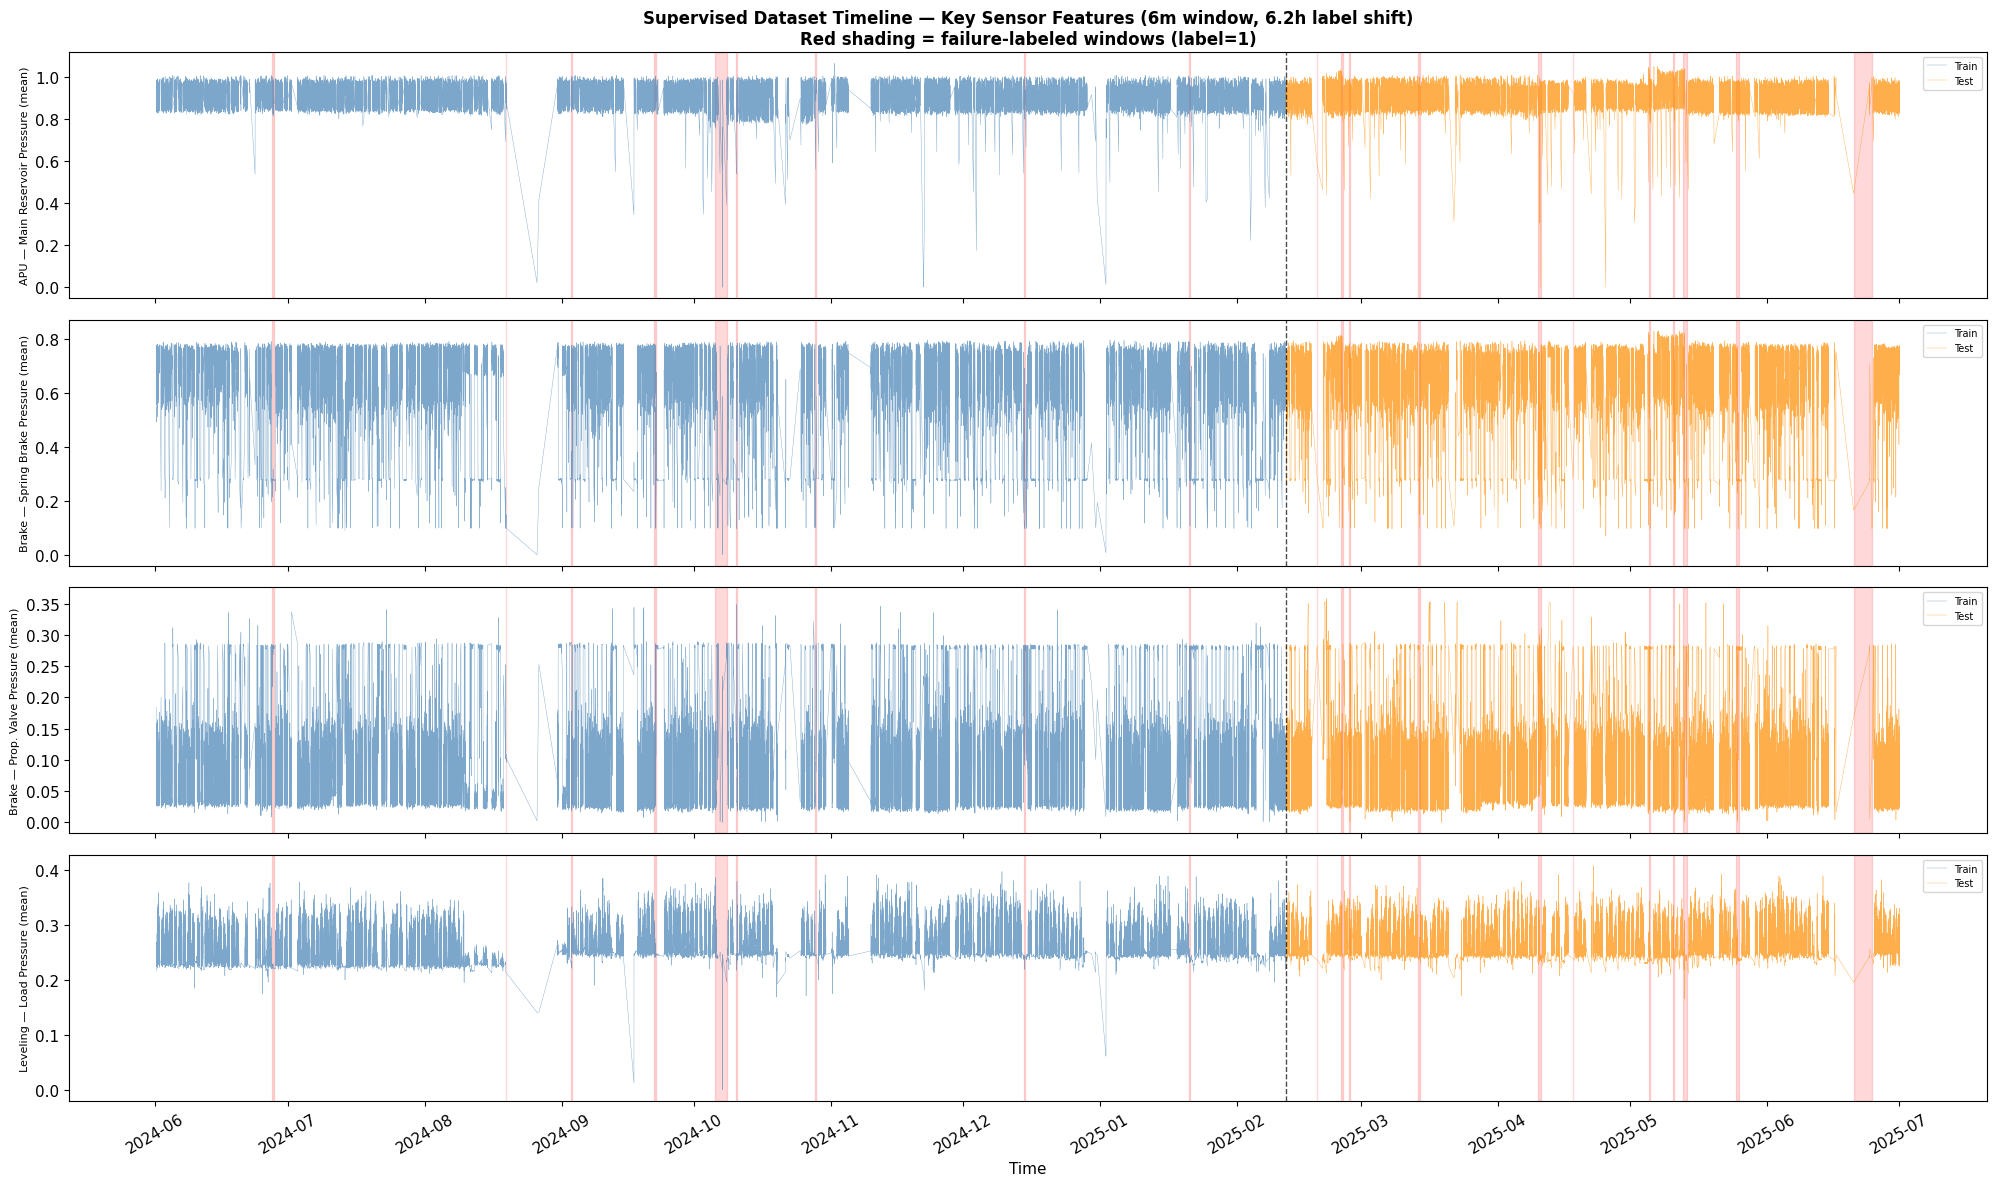

Saved: outputs/timeline_supervised_features.png


In [22]:
# Timeline plot: key sensor features over the full period (train + test)
# Select representative features — one per subsystem
TIMELINE_FEATURES = {
    'APU — Main Reservoir Pressure (mean)': 'CW1_MAIN_RESERVOIR_PRESSURE_mean',
    'Brake — Spring Brake Pressure (mean)': 'CW1_SPRING_BRAKE_PRESSURE_BOGIE1_mean',
    'Brake — Prop. Valve Pressure (mean)': 'CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1_mean',
    'Leveling — Load Pressure (mean)': 'CW1_LOAD_PRESSURE_BOGIE1_mean',
}

# Identify failure windows for shading
failure_mask = sup_all["label"] == 1
fail_starts = []
fail_ends = []
in_fail = False
for i, row in sup_all.iterrows():
    if row["label"] == 1 and not in_fail:
        fail_starts.append(row["window_end"])
        in_fail = True
    elif row["label"] == 0 and in_fail:
        fail_ends.append(sup_all.loc[i-1, "window_end"])
        in_fail = False
if in_fail:
    fail_ends.append(sup_all["window_end"].iloc[-1])

split_date = sup_train["window_end"].max()

fig, axes = plt.subplots(len(TIMELINE_FEATURES), 1, figsize=(20, 3 * len(TIMELINE_FEATURES)), sharex=True)

for ax, (title, col) in zip(axes, TIMELINE_FEATURES.items()):
    # Plot train and test in different colors
    train_mask = sup_all["split"] == "train"
    ax.plot(sup_all.loc[train_mask, "window_end"], sup_all.loc[train_mask, col],
            linewidth=0.3, color="steelblue", alpha=0.7, label="Train")
    ax.plot(sup_all.loc[~train_mask, "window_end"], sup_all.loc[~train_mask, col],
            linewidth=0.3, color="darkorange", alpha=0.7, label="Test")

    # Shade failure windows
    for fs, fe in zip(fail_starts, fail_ends):
        ax.axvspan(fs, fe, color="red", alpha=0.15, zorder=0)

    # Train/test split
    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_ylabel(title, fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

axes[0].set_title(
    "Supervised Dataset Timeline — Key Sensor Features (6m window, 6.2h label shift)\n"
    "Red shading = failure-labeled windows (label=1)",
    fontsize=12, fontweight="bold"
)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].set_xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/timeline_supervised_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/timeline_supervised_features.png")

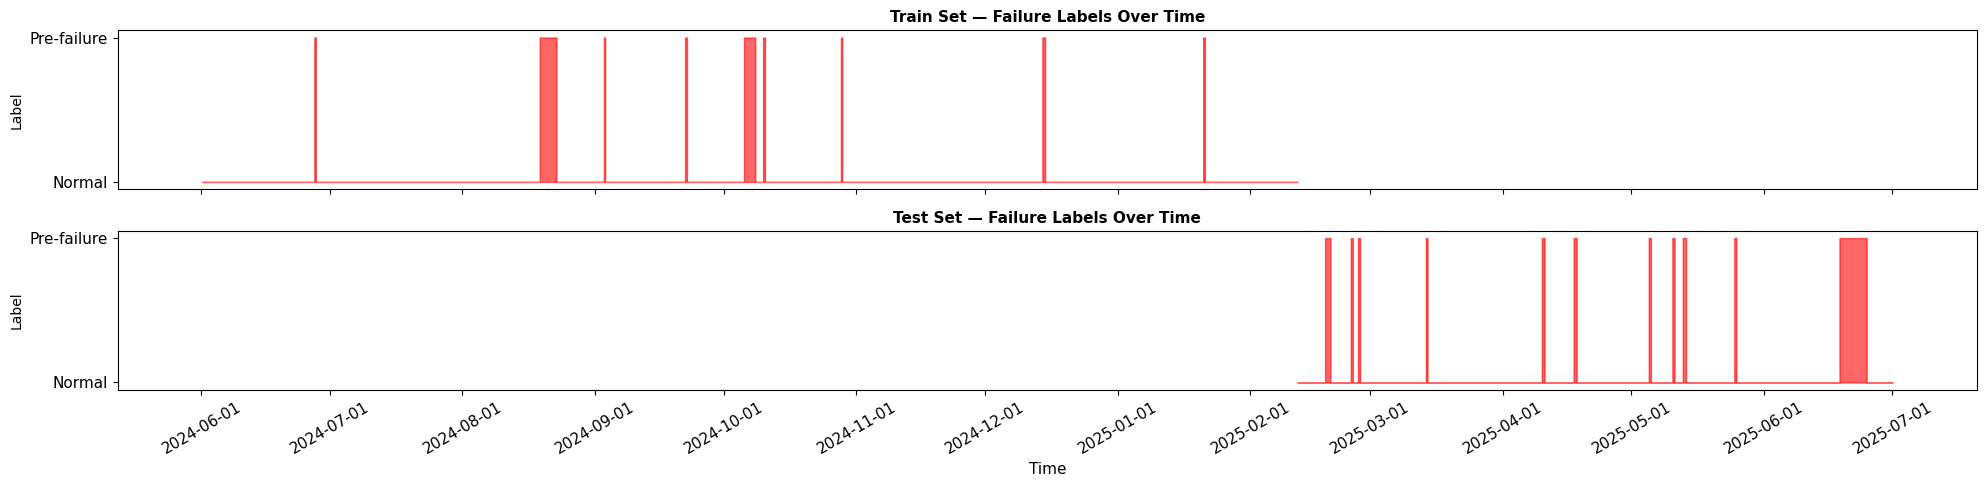

Train: 40517 windows | label=1: 518 (1.3%) | label=0: 39999
Test: 21554 windows | label=1: 583 (2.7%) | label=0: 20971


In [23]:
# Label timeline: show label=1 windows as a binary signal over time
fig, axes = plt.subplots(2, 1, figsize=(20, 5), sharex=True)

# Train
ax = axes[0]
ax.fill_between(sup_train["window_end"], sup_train["label"], step="mid", color="red", alpha=0.6)
ax.set_ylabel("Label", fontsize=10)
ax.set_title("Train Set — Failure Labels Over Time", fontsize=11, fontweight="bold")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Normal", "Pre-failure"])

# Test
ax = axes[1]
ax.fill_between(sup_test["window_end"], sup_test["label"], step="mid", color="red", alpha=0.6)
ax.set_ylabel("Label", fontsize=10)
ax.set_title("Test Set — Failure Labels Over Time", fontsize=11, fontweight="bold")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Normal", "Pre-failure"])

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].set_xlabel("Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Print failure event statistics per split
for label, df in [("Train", sup_train), ("Test", sup_test)]:
    n_pos = (df["label"] == 1).sum()
    n_neg = (df["label"] == 0).sum()
    ratio = n_pos / len(df) * 100
    print(f"{label}: {len(df)} windows | label=1: {n_pos} ({ratio:.1f}%) | label=0: {n_neg}")

Steiner test set (above threshold): 1674 windows
Period: 2025-02-16 22:59:10 to 2025-05-27 05:48:20
True label=1: 239
Pred label=1: 1674
Probability range: 0.1500 to 0.5989


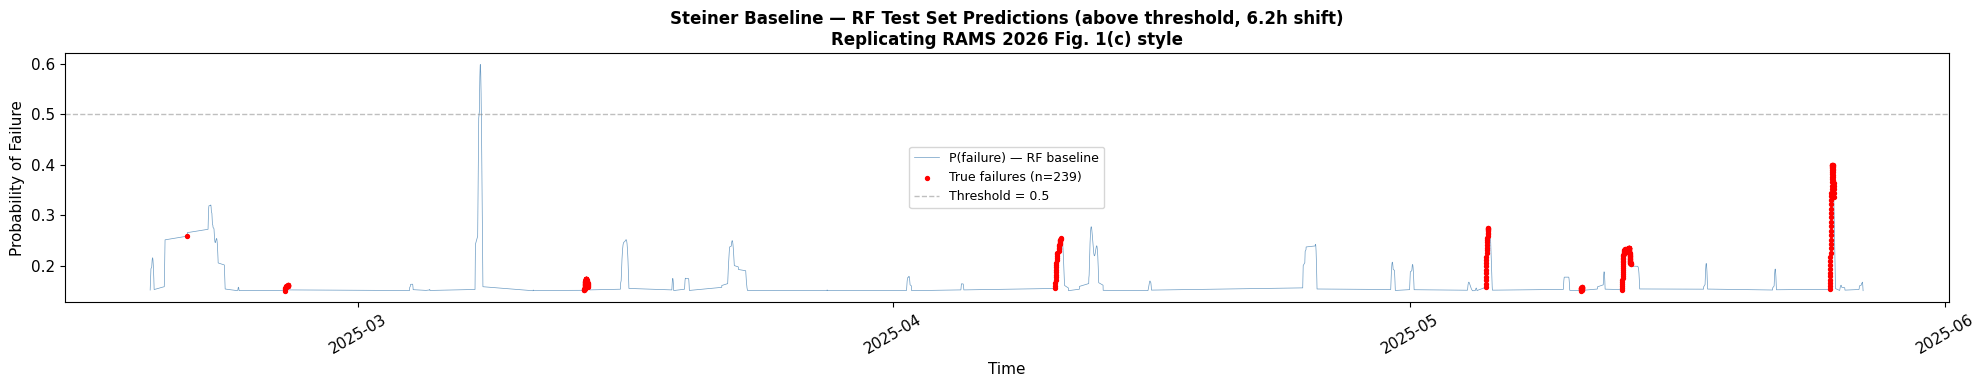

Saved: outputs/steiner_baseline_timeline.png


In [24]:
# Compare with Steiner's baseline test set (above threshold)
steiner_csv = Path(r"C:\Users\Emırhan\Desktop\MASTER THESIS\Kurtulus-thesis\references\stefan\supervised_test_predictions.csv")
steiner_df = pd.read_csv(steiner_csv)
steiner_df["window_end"] = pd.to_datetime(steiner_df["window_end"])
steiner_df["timestamp"] = pd.to_datetime(steiner_df["timestamp"])

print(f"Steiner test set (above threshold): {len(steiner_df)} windows")
print(f"Period: {steiner_df['window_end'].min()} to {steiner_df['window_end'].max()}")
print(f"True label=1: {steiner_df['6_2_h_shifted_true_failure_label'].sum()}")
print(f"Pred label=1: {steiner_df['6_2_h_shifted_predicted_failure_label'].sum()}")
print(f"Probability range: {steiner_df['probability_of_failure'].min():.4f} to {steiner_df['probability_of_failure'].max():.4f}")

# Plot Steiner's predictions over time (replicating Fig 1(c))
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(steiner_df["window_end"], steiner_df["probability_of_failure"],
        linewidth=0.5, color="steelblue", alpha=0.8, label="P(failure) — RF baseline")

# Mark true failure windows
true_fail = steiner_df[steiner_df["6_2_h_shifted_true_failure_label"] == 1]
ax.scatter(true_fail["window_end"], true_fail["probability_of_failure"],
           color="red", s=8, zorder=5, label=f"True failures (n={len(true_fail)})")

# Decision threshold (Steiner uses probability > some threshold)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.5, label="Threshold = 0.5")

ax.set_xlabel("Time")
ax.set_ylabel("Probability of Failure")
ax.set_title("Steiner Baseline — RF Test Set Predictions (above threshold, 6.2h shift)\n"
             "Replicating RAMS 2026 Fig. 1(c) style", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/steiner_baseline_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/steiner_baseline_timeline.png")